# Task 1 — Data Ingestion & Conditioning (REAL DATA)

**Member A's job:** turn each raw drone recording into 3 clean things the team needs:

| Output | Meaning |
|---|---|
| `iq`   | the radio signal, as complex numbers `I + jQ` |
| `mask` | True where the drone is **talking**, False where **silent** |
| `meta` | info: sample rate, center frequency, drone, source file |

**Our two real files (DroneDetect):**
- `AH Sample/AIR_0001_00.dat` — DJI Mavic **Air**, clean condition
- `AH Sample/MA1_0001_00.dat` — DJI **Mavic (Pro)**, clean condition

Each is ~2 seconds, 120 million complex samples, recorded at 60 MS/s.

We do 4 steps: **Read → Standardize → Normalize → Detect activity**, then save
one `.npz` per drone for Member B.

## Setup

In [1]:
import numpy as np
import scipy.signal as sig
from scipy.ndimage import uniform_filter1d
import matplotlib.pyplot as plt
%matplotlib inline

# Real capture settings, confirmed from the dataset + official load_data.py
FS = 60_000_000        # 60 million samples per second
FC = 2.4375e9          # center frequency 2.4375 GHz
print("ready. FS =", FS, "Hz, FC =", FC/1e9, "GHz")

ready. FS = 60000000 Hz, FC = 2.4375 GHz


## Step 1 — Read the file into complex numbers

The official `load_data.py` tells us the exact format:
- numbers are **float32**, stored interleaved `[I0,Q0,I1,Q1,...]`
- reading them as float32 then `.view(complex64)` re-pairs them into `I + jQ`

That's all "reading" is: bytes on disk → complex numbers.

In [2]:
def read_iq(path):
    raw = np.fromfile(path, dtype="float32")   # read all float32 numbers
    iq = raw.view(np.complex64)                # re-pair as I + jQ
    return iq

iq_air = read_iq("AH Sample/AIR_0001_00.dat")
print(f"AIR: {len(iq_air):,} complex samples ({len(iq_air)/FS:.2f} seconds)")
print("first 3 samples:", iq_air[:3])

AIR: 120,000,000 complex samples (2.00 seconds)
first 3 samples: [0.04980469+0.08496094j 0.05224609+0.08935547j 0.05029297+0.09277344j]


### Sanity check: the spectrogram (the 2-minute step that saves days)
A picture of signal energy over time & frequency. A correct read shows clear
bright **bursts**. Pure fuzz would mean we read the format wrong.

(We plot only the first 2 million samples so it's fast — that's ~33 ms of signal.)

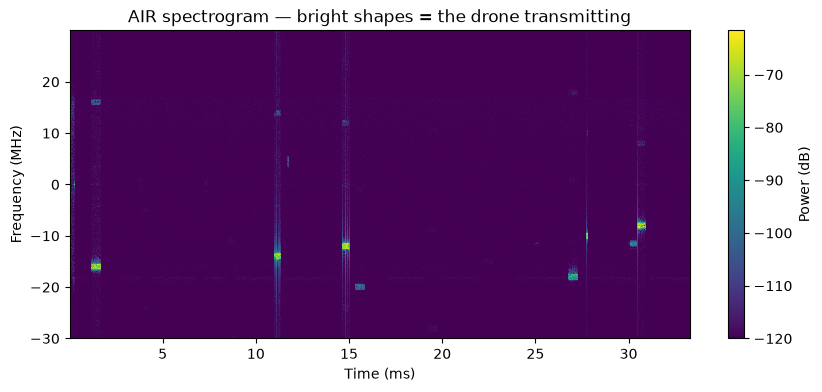

In [3]:
chunk = iq_air[:2_000_000]
f, tt, Sxx = sig.spectrogram(chunk, fs=FS, nperseg=4096, return_onesided=False)
plt.figure(figsize=(10,4))
plt.pcolormesh(tt*1e3, np.fft.fftshift(f)/1e6,
               10*np.log10(np.fft.fftshift(Sxx, axes=0)+1e-12), shading="auto")
plt.ylabel("Frequency (MHz)"); plt.xlabel("Time (ms)")
plt.title("AIR spectrogram — bright shapes = the drone transmitting")
plt.colorbar(label="Power (dB)"); plt.show()

## Step 2 — Standardize (sample rate & center frequency)

Nothing to convert here: both files come from the same recorder, so they already
share `FS = 60 MS/s` and `FC = 2.4375 GHz`. We just record these values.
(If two files ever differed, this is where we'd resample or frequency-shift.)

In [4]:
print(f"Both drones share FS = {FS} Hz and FC = {FC/1e9} GHz  -> no conversion needed")

Both drones share FS = 60000000 Hz and FC = 2.4375 GHz  -> no conversion needed


## Step 3 — Normalize the volume

We use the SAME normalization as the official script: subtract the mean and
divide by the standard deviation. This makes the signal's power consistent, so
one drone isn't 'louder' than the other just because of recording gain.

In [5]:
def normalize(iq):
    iq = (iq - iq.mean()) / np.sqrt(iq.var())
    return iq.astype(np.complex64)

iq_air = normalize(iq_air)
print("after normalize: mean power =", float(np.mean(np.abs(iq_air)**2)))

after normalize: mean power = 1.000000238418579


## Step 4 — Detect activity (the main product)

Decide for every sample: is the drone talking or silent?
1. **Power envelope** — smooth |iq|² over a short window → a 'loudness over time' curve.
2. **Threshold** — a line a few× above the median (median ≈ the quiet noise floor).
3. `mask = envelope > threshold`.

We use a fast sliding-average (`uniform_filter1d`) because the file has 120M samples.

In [6]:
def activity_mask(iq, fs, win_ms=0.2, k=5.0):
    win = max(1, int(win_ms/1000 * fs))          # window length in samples
    power = (iq.real**2 + iq.imag**2).astype(np.float32)
    env = uniform_filter1d(power, size=win)      # smoothed loudness
    thr = k * np.median(env)                      # threshold above noise floor
    mask = env > thr
    return mask, env, thr, win

mask_air, env_air, thr_air, win = activity_mask(iq_air, FS)
print(f"window = {win} samples ({win/FS*1e3:.2f} ms), threshold = {thr_air:.4f}")
print(f"AIR is 'talking' {100*mask_air.mean():.1f}% of the recording")

window = 12000 samples (0.20 ms), threshold = 0.0024
AIR is 'talking' 11.2% of the recording


### Clean up the mask (fast)
Fill tiny holes and drop tiny specks so each burst is one solid block. We do it
cheaply by smoothing the True/False mask and re-thresholding (no slow loops).

In [7]:
def clean_mask(mask, win):
    smooth = uniform_filter1d(mask.astype(np.float32), size=win)
    return smooth > 0.5

mask_air = clean_mask(mask_air, win)
print(f"after cleanup: talking {100*mask_air.mean():.1f}% of the time")

after cleanup: talking 11.2% of the time


### See it: signal loudness + detected mask
Blue = how loud the signal is. Orange = where we decided the drone is talking.
The orange blocks should sit exactly on top of the loud bursts.
(We plot a downsampled version so 120M points render quickly.)

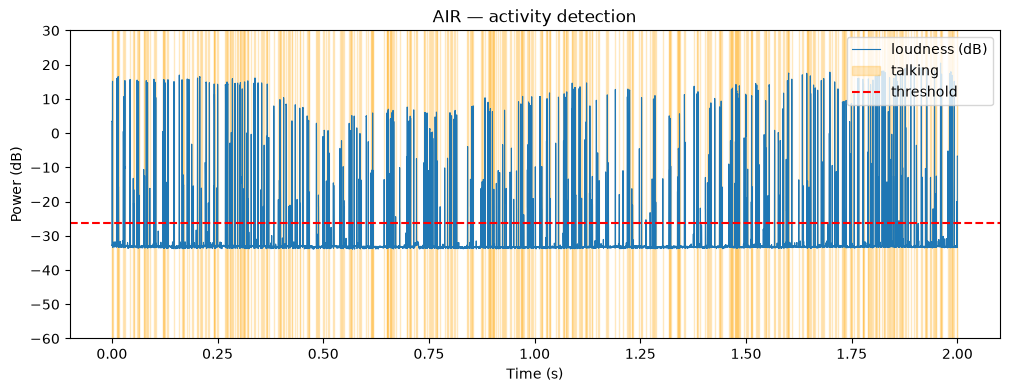

In [8]:
def plot_activity(env, mask, thr, fs, title, step=2000):
    e = env[::step]; m = mask[::step]
    t = np.arange(len(e)) * step / fs
    plt.figure(figsize=(12,4))
    plt.plot(t, 10*np.log10(e+1e-12), lw=0.8, label="loudness (dB)")
    plt.fill_between(t, -60, 30, where=m, alpha=0.25, color="orange", label="talking")
    plt.axhline(10*np.log10(thr), color="red", ls="--", label="threshold")
    plt.ylim(-60, 30); plt.xlabel("Time (s)"); plt.ylabel("Power (dB)")
    plt.title(title); plt.legend(loc="upper right"); plt.show()

plot_activity(env_air, mask_air, thr_air, FS, "AIR — activity detection")

## Do everything in one function
Now wrap all 4 steps so we can run each drone in one line.

In [9]:
def load_and_condition(path, fs, fc, drone, condition="clean"):
    iq = read_iq(path)
    iq = normalize(iq)
    mask, env, thr, win = activity_mask(iq, fs)
    mask = clean_mask(mask, win)
    meta = {"fs_hz": fs, "fc_hz": fc, "drone": drone,
            "condition": condition, "source_file": path}
    return iq, mask, meta, env, thr

## Run BOTH drones and save the outputs for Member B

In [10]:
# Drone 1 = AIR (already loaded, but re-run cleanly for consistency)
iq1, mask1, meta1, env1, thr1 = load_and_condition(
    "AH Sample/AIR_0001_00.dat", FS, FC, "DJI_Mavic_Air")
np.savez("droneAIR_conditioned.npz", iq=iq1, mask=mask1,
         meta=np.array([meta1], dtype=object))
print("saved droneAIR_conditioned.npz | talking %.1f%%" % (100*mask1.mean()))

# Drone 2 = MA1
iq2, mask2, meta2, env2, thr2 = load_and_condition(
    "AH Sample/MA1_0001_00.dat", FS, FC, "DJI_Mavic_Pro")
np.savez("droneMA1_conditioned.npz", iq=iq2, mask=mask2,
         meta=np.array([meta2], dtype=object))
print("saved droneMA1_conditioned.npz | talking %.1f%%" % (100*mask2.mean()))

saved droneAIR_conditioned.npz | talking 11.2%


saved droneMA1_conditioned.npz | talking 8.7%


### Compare the two drones side by side

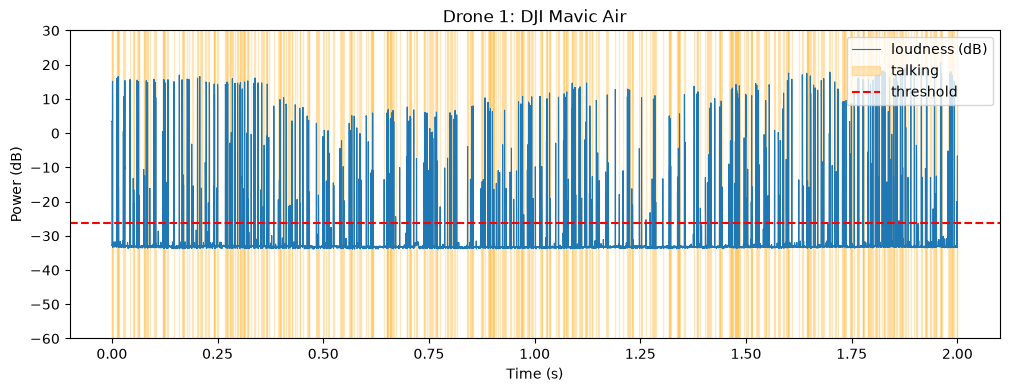

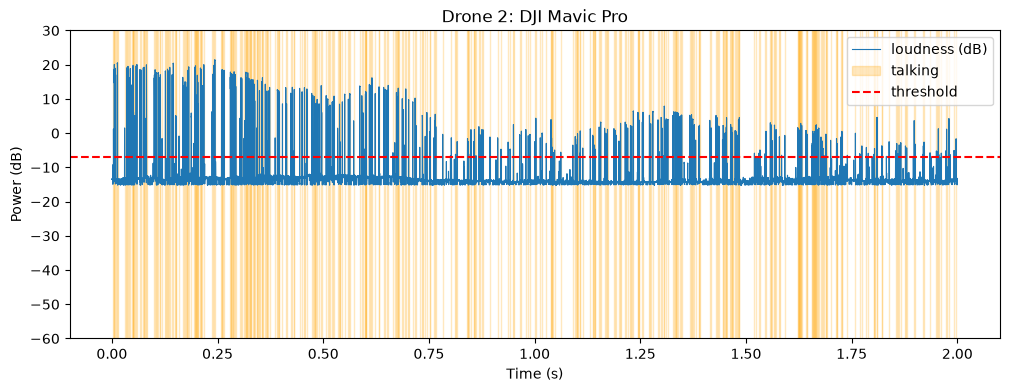

In [11]:
plot_activity(env1, mask1, thr1, FS, "Drone 1: DJI Mavic Air")
plot_activity(env2, mask2, thr2, FS, "Drone 2: DJI Mavic Pro")

## ✅ Task 1 done — what you produced

Two files, each holding `iq` + `mask` + `meta`:
- `droneAIR_conditioned.npz`  (DJI Mavic Air)
- `droneMA1_conditioned.npz`  (DJI Mavic Pro)

**Hand these two `.npz` files to Member B.** They contain everything the TDMA
overlay step needs: the clean signal and exactly when each drone is transmitting.

### If you want to tune it
- `k` (in `activity_mask`) = threshold height. Higher = stricter (less 'talking').
- `win_ms` = smoothing window. Bigger = smoother mask, but blurs short bursts.
- Look at the orange plot: orange should cover the loud parts and nothing else.